In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import yaml

# %matplotlib tk

In [2]:
energy_df = pd.read_excel('Dataset.xlsx', sheet_name='2023 data', usecols='A:F', nrows=8762)
meta_data = yaml.safe_load(open("meta_data.yml", "r"))
energy_df.tail()

,Date,PV generation (kW),Consumption (kW),Consumption (pu),Energy price (EUR/MWh),Energy price (EUR/kWh)
8755,2023-12-31 19:00:00,0,2038,0.171751,101.30,0.10130
8756,2023-12-31 20:00:00,0,2013,0.169644,92.97,0.09297
8757,2023-12-31 21:00:00,0,2026,0.170740,85.49,0.08549
8758,2023-12-31 22:00:00,0,2027,0.170824,74.74,0.07474
8759,2023-12-31 23:00:00,0,2027,0.170824,71.96,0.07196


In [3]:
generated_dir = "generated_zero_noise"
if not os.path.exists(generated_dir):
    raise FileNotFoundError(f"Directory '{generated_dir}' does not exist. Please create it and add the generated data files.")

## Simulated Real-Time prices

In [4]:
rt_prices_df = pd.read_csv(os.path.join(generated_dir, 'simulated_rt_prices_year.csv'))
rt_prices_df["Date"] = pd.to_datetime(rt_prices_df["Date"])
rt_prices_df.head()

,RT energy price (EUR/kWh),Date
0,0.0,2023-01-01 00:00:00
1,0.0,2023-01-01 01:00:00
2,0.0,2023-01-01 02:00:00
3,0.0,2023-01-01 03:00:00
4,0.0,2023-01-01 04:00:00


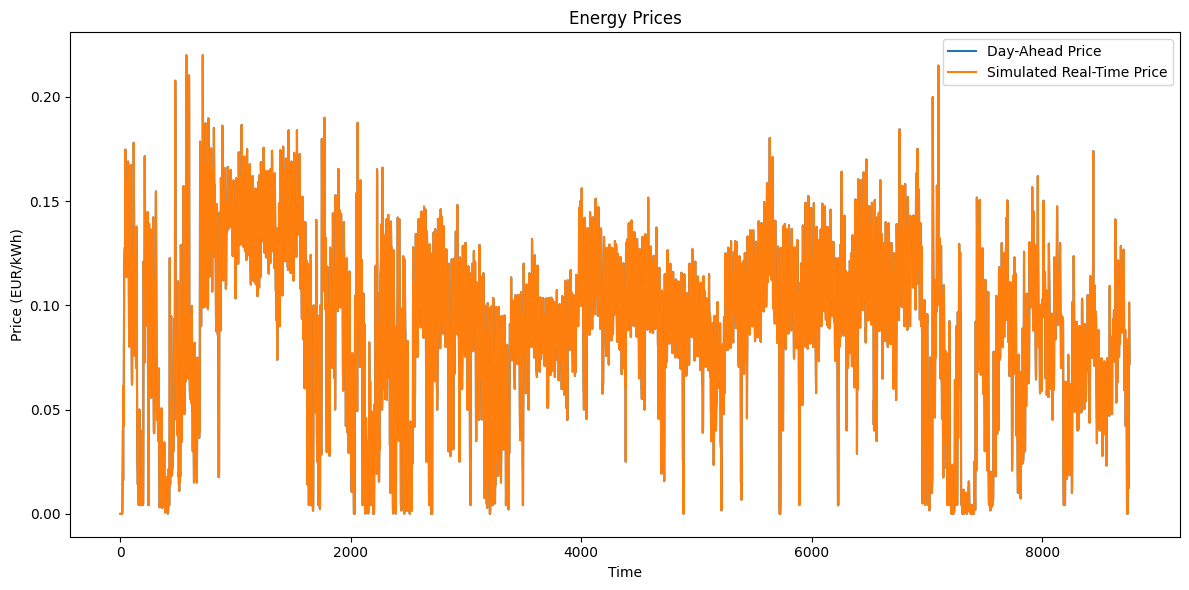

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(energy_df['Energy price (EUR/kWh)'], label='Day-Ahead Price')
plt.plot(rt_prices_df['RT energy price (EUR/kWh)'], label='Simulated Real-Time Price')
plt.title(f"Energy Prices")
plt.xlabel('Time')
plt.ylabel('Price (EUR/kWh)')
plt.legend()
plt.tight_layout()

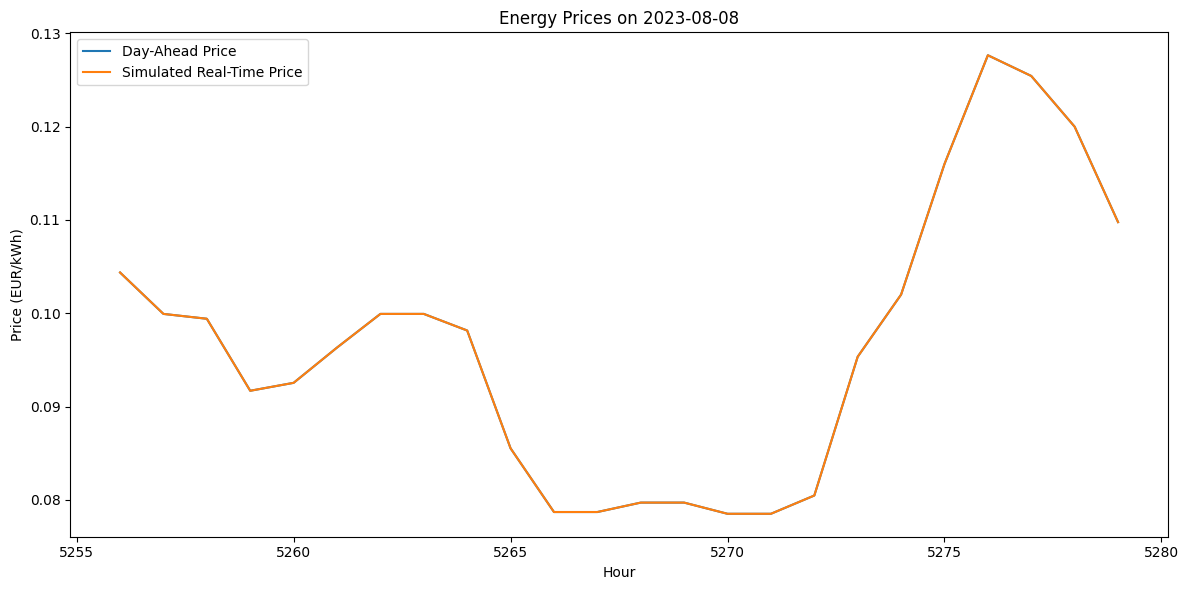

In [6]:
date = "2023-08-08"
day_rt_prices = rt_prices_df[rt_prices_df['Date'].dt.date == pd.to_datetime(date).date()]
day_da_prices = energy_df[energy_df['Date'].dt.date == pd.to_datetime(date).date()]

plt.figure(figsize=(12, 6))
plt.plot(day_da_prices['Energy price (EUR/kWh)'], label='Day-Ahead Price')
plt.plot(day_rt_prices['RT energy price (EUR/kWh)'], label='Simulated Real-Time Price')
plt.title(f"Energy Prices on {date}")
plt.xlabel("Hour")
plt.ylabel("Price (EUR/kWh)")
plt.legend()
plt.tight_layout()

## Checking the generated data

In [7]:
perfect_foresight_df = pd.read_csv(os.path.join(generated_dir, 'perfect_foresight_optimization_year.csv'))
perfect_foresight_df['Date'] = pd.to_datetime(perfect_foresight_df['Date'])
perfect_foresight_df.head()

,Date,pv,load,price,export_price,grid_import,grid_export,battery_1_charge,battery_1_discharge,battery_1_soc,battery_2_charge,battery_2_discharge,battery_2_soc
0,2023-01-01 00:00:00,0.0,2313.0,0.0,0.0,2881.421053,0.0,68.421053,0.0,215.0,500.000000,0.0,800.0
1,2023-01-01 01:00:00,0.0,2308.0,0.0,0.0,2530.222222,0.0,0.000000,0.0,215.0,222.222222,0.0,1000.0
2,2023-01-01 02:00:00,0.0,2308.0,0.0,0.0,2308.000000,0.0,0.000000,0.0,215.0,0.000000,0.0,1000.0
3,2023-01-01 03:00:00,0.0,2306.0,0.0,0.0,2306.000000,0.0,0.000000,0.0,215.0,0.000000,0.0,1000.0
4,2023-01-01 04:00:00,0.0,2306.0,0.0,0.0,2306.000000,0.0,0.000000,0.0,215.0,0.000000,0.0,1000.0


In [8]:
num_scenarios = 3

stochastic_optim_df = pd.read_csv(os.path.join(generated_dir, f'stochastic_optimization_with_{num_scenarios}_scenarios_year.csv'))
stochastic_optim_df['Date'] = pd.to_datetime(stochastic_optim_df['Date'])
stochastic_optim_df.head()

,Date,price_ahead,grid_import,grid_import_ahead,expected_grid_import_rt,expected_grid_export_rt,expected_battery_1_charge,expected_battery_1_discharge,expected_battery_1_soc,expected_battery_2_charge,expected_battery_2_discharge,expected_battery_2_soc
0,2023-01-01 00:00:00,0.0,2192.000000,2192.00,0.000000e+00,0.0,167.680400,0.000000,309.281380,168.500000,0.000000e+00,501.615000
1,2023-01-01 01:00:00,0.0,1747.000000,1747.00,1.360149e-13,0.0,101.100000,134.174200,264.090380,0.000000,7.582500e+01,417.365000
2,2023-01-01 02:00:00,0.0,1940.560000,1940.56,-9.578116e-15,0.0,7.801632,81.717688,185.483311,168.500000,0.000000e+00,569.015000
3,2023-01-01 03:00:00,0.0,1919.112479,1468.00,4.511125e+02,0.0,154.466207,0.069006,332.153571,92.377778,1.796240e+02,452.572778
4,2023-01-01 04:00:00,0.0,2259.389375,1898.25,3.611394e+02,0.0,124.771800,91.242750,354.641781,376.350000,-1.724061e-13,791.287778


In [9]:
file_path = os.path.join(generated_dir, f'stochastic_optimization_with_{num_scenarios}_scenarios_year_zero_noise.csv')
zero_noise_data_exists = os.path.exists(file_path)

if zero_noise_data_exists:
    stochastic_optim_zero_noise_df = pd.read_csv(file_path)
    stochastic_optim_zero_noise_df['Date'] = pd.to_datetime(stochastic_optim_zero_noise_df['Date'])
    stochastic_optim_zero_noise_df.head()

In [10]:
stochastic_policy_evaluation_df = pd.read_csv(os.path.join(generated_dir, f'stochastic_policy_evaluation_with_{num_scenarios}_scenarios_year.csv'))
stochastic_policy_evaluation_df['Date'] = pd.to_datetime(stochastic_policy_evaluation_df['Date'])
stochastic_policy_evaluation_df.head()

,Date,price_ahead,grid_import,grid_import_ahead,expected_grid_import_rt,expected_grid_export_rt,expected_battery_1_charge,expected_battery_1_discharge,expected_battery_1_soc,expected_battery_2_charge,expected_battery_2_discharge,expected_battery_2_soc
0,2023-01-01 00:00:00,0.0,2192.000000,2192.00,0.000000,0.000000e+00,0.0,95.0,50.0,0.000000,26.0,321.111111
1,2023-01-01 01:00:00,0.0,3108.000000,1747.00,1361.000000,-2.273737e-12,300.0,0.0,335.0,500.000000,0.0,771.111111
2,2023-01-01 02:00:00,0.0,1940.560000,1940.56,0.000000,5.656000e+01,0.0,0.0,335.0,0.000000,424.0,300.000000
3,2023-01-01 03:00:00,0.0,2306.000000,1468.00,838.000000,0.000000e+00,0.0,0.0,335.0,0.000000,0.0,300.000000
4,2023-01-01 04:00:00,0.0,2583.777778,1898.25,685.527778,0.000000e+00,0.0,0.0,335.0,277.777778,0.0,550.000000


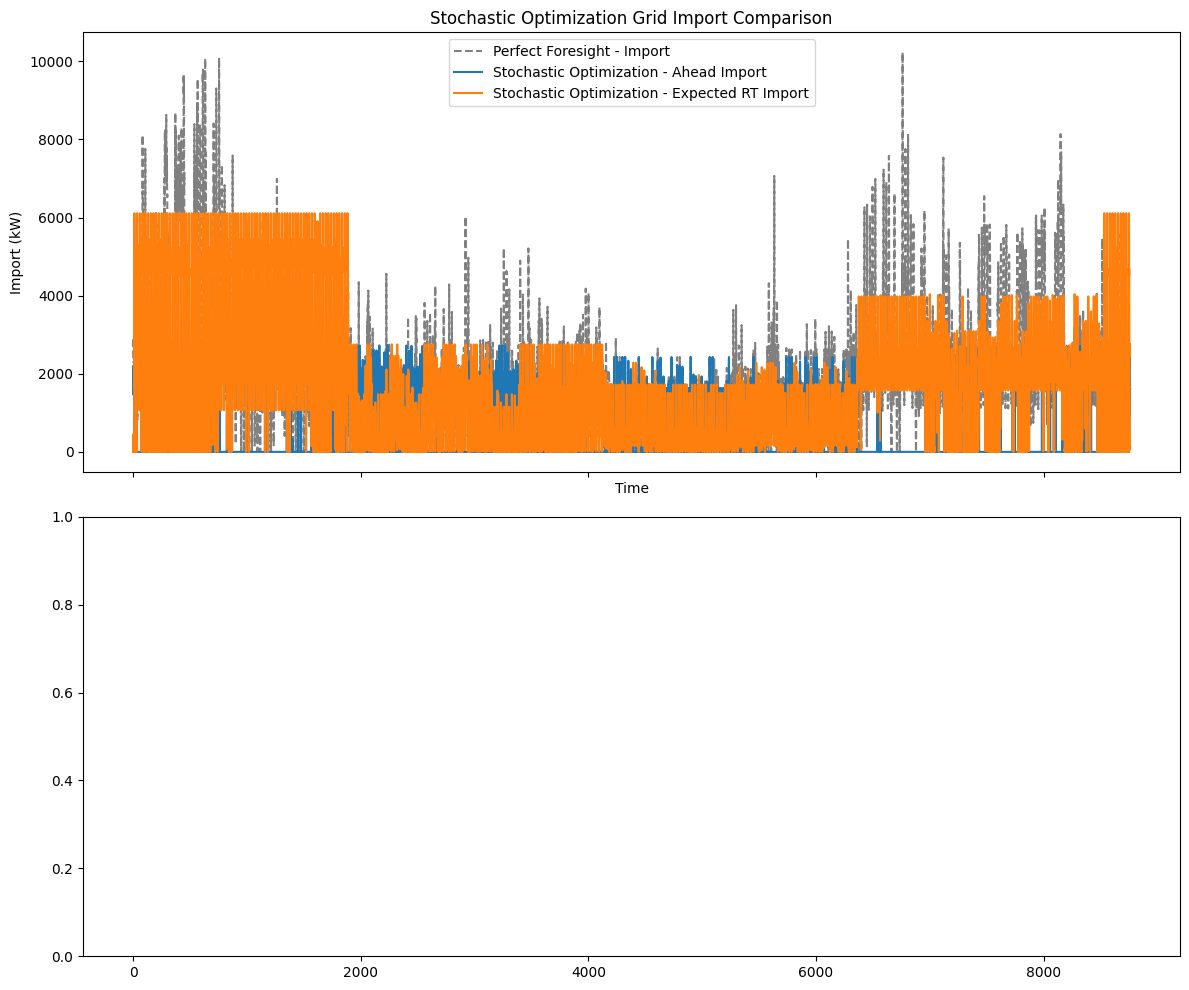

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axs[0].plot(perfect_foresight_df['grid_import'], '--', c='grey', label='Perfect Foresight - Import')
axs[0].plot(stochastic_optim_df['grid_import_ahead'], label='Stochastic Optimization - Ahead Import')
axs[0].plot(stochastic_optim_df['expected_grid_import_rt'], label='Stochastic Optimization - Expected RT Import')
axs[0].legend()
axs[0].set_title('Stochastic Optimization Grid Import Comparison')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Import (kW)')

if zero_noise_data_exists:
    axs[1].plot(perfect_foresight_df['grid_import'], '--', c='grey', label='Perfect Foresight - Import')
    axs[1].plot(stochastic_optim_zero_noise_df['grid_import_ahead'], label='Stochastic Optimization (Zero Noise) - Ahead Import')
    axs[1].plot(stochastic_optim_zero_noise_df['expected_grid_import_rt'], label='Stochastic Optimization (Zero Noise) - Expected RT Import')
    axs[1].legend()
    # axs[1].set_title('Stochastic Optimization Ahead Grid Import Comparison')
    axs[1].set_xlabel('Time')
    axs[1].set_ylabel('Import (kW)')

plt.tight_layout()

In [12]:
stochastic_final_df = stochastic_optim_df.merge(stochastic_policy_evaluation_df, on='Date', suffixes=('_optimization', '_evaluation'), how='left')

stochastic_final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Date                                       8760 non-null   datetime64[ns]
 1   price_ahead_optimization                   8760 non-null   float64       
 2   grid_import_optimization                   8760 non-null   float64       
 3   grid_import_ahead_optimization             8760 non-null   float64       
 4   expected_grid_import_rt_optimization       8760 non-null   float64       
 5   expected_grid_export_rt_optimization       8760 non-null   float64       
 6   expected_battery_1_charge_optimization     8760 non-null   float64       
 7   expected_battery_1_discharge_optimization  8760 non-null   float64       
 8   expected_battery_1_soc_optimization        8760 non-null   float64       
 9   expected_battery_2_

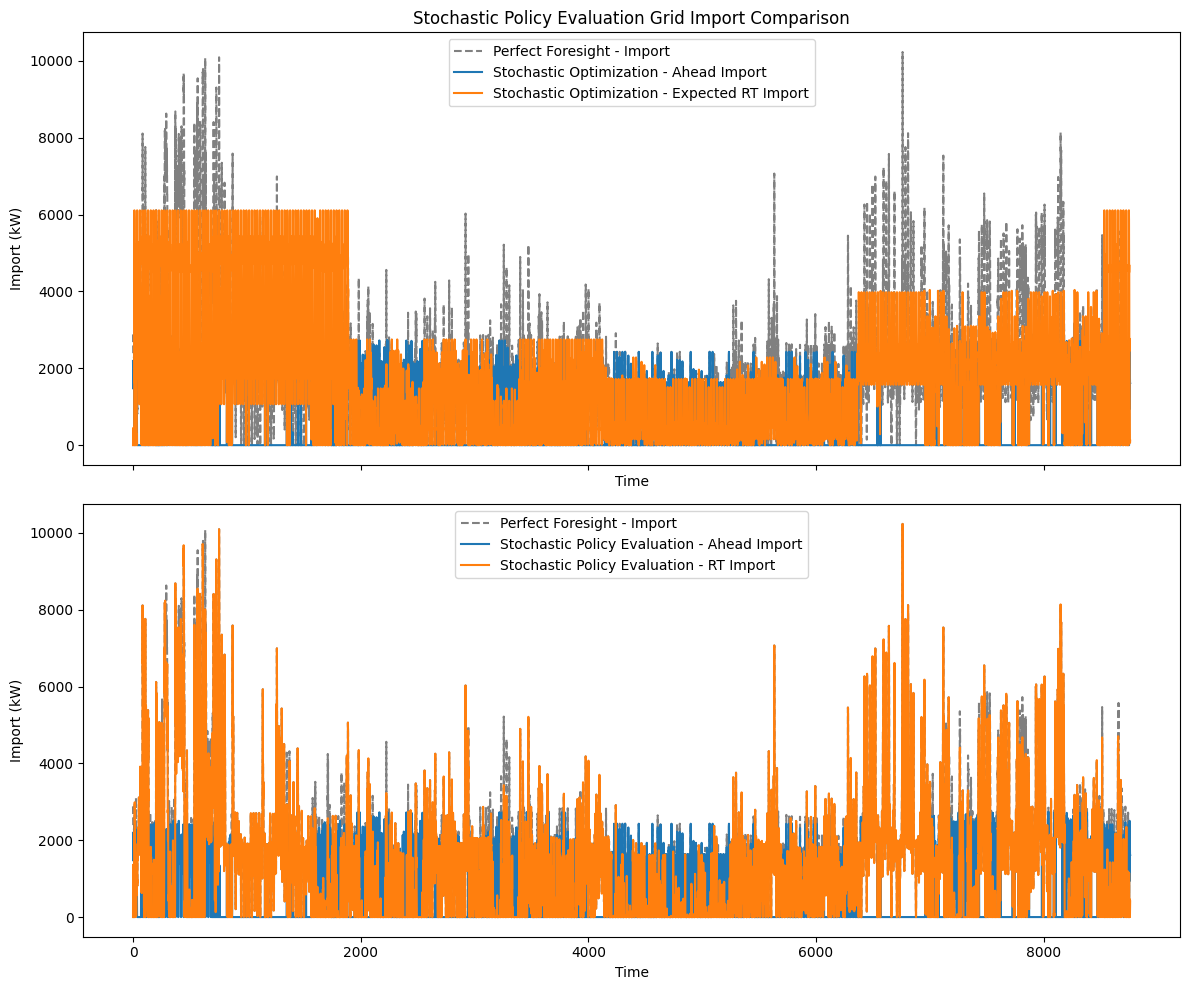

In [13]:
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

axs[0].plot(perfect_foresight_df['grid_import'], '--', c='grey', label='Perfect Foresight - Import')
axs[0].plot(stochastic_final_df['grid_import_ahead_optimization'], label='Stochastic Optimization - Ahead Import')
axs[0].plot(stochastic_final_df['expected_grid_import_rt_optimization'], label='Stochastic Optimization - Expected RT Import')
axs[0].legend()
axs[0].set_title('Stochastic Policy Evaluation Grid Import Comparison')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Import (kW)')

axs[1].plot(perfect_foresight_df['grid_import'], '--', c='grey', label='Perfect Foresight - Import')
axs[1].plot(stochastic_final_df['grid_import_ahead_evaluation'], label='Stochastic Policy Evaluation - Ahead Import')
axs[1].plot(stochastic_final_df['expected_grid_import_rt_evaluation'], label='Stochastic Policy Evaluation - RT Import')
axs[1].legend()
# axs[1].set_title('Stochastic Optimization Ahead Grid Import Comparison')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Import (kW)')

plt.tight_layout()

Number of days evaluated: 365


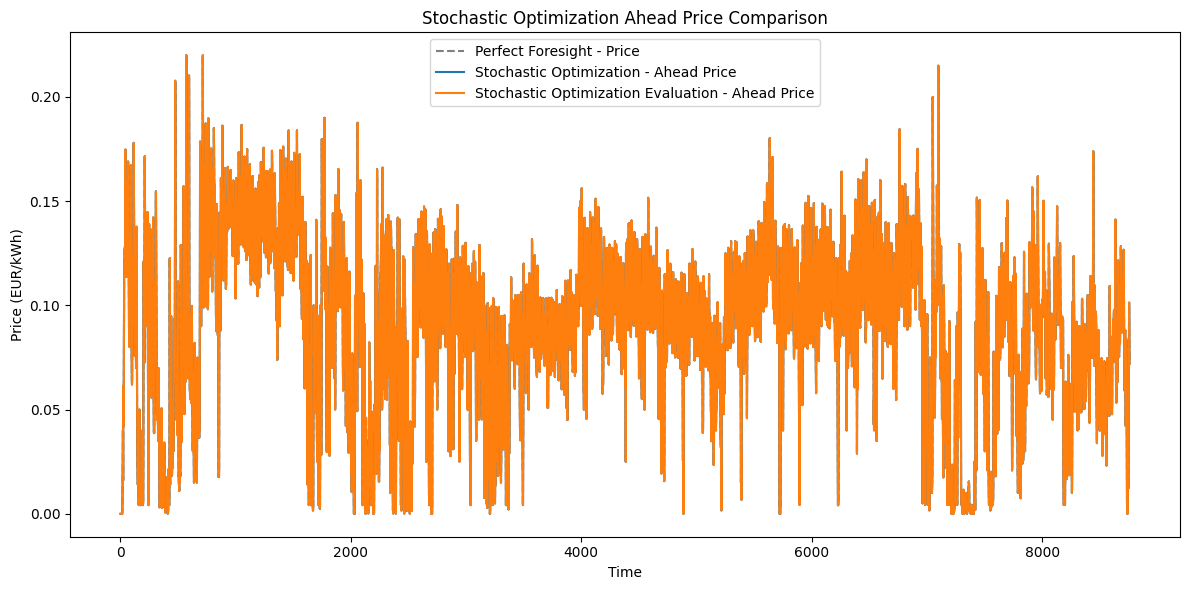

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(perfect_foresight_df['price'], '--', c='grey', label='Perfect Foresight - Price')
plt.plot(stochastic_final_df['price_ahead_optimization'], label='Stochastic Optimization - Ahead Price')
plt.plot(stochastic_final_df['price_ahead_evaluation'], label='Stochastic Optimization Evaluation - Ahead Price')

plt.legend()
plt.title('Stochastic Optimization Ahead Price Comparison')
plt.xlabel('Time')
plt.ylabel('Price (EUR/kWh)')
plt.tight_layout()

non_nans = ~stochastic_final_df['price_ahead_evaluation'].isna()
print(f"Number of days evaluated: {len(non_nans) // 24}")
assert np.allclose(stochastic_final_df['price_ahead_optimization'][non_nans], stochastic_final_df['price_ahead_evaluation'][non_nans], atol=1e-3), "Prices do not match!"

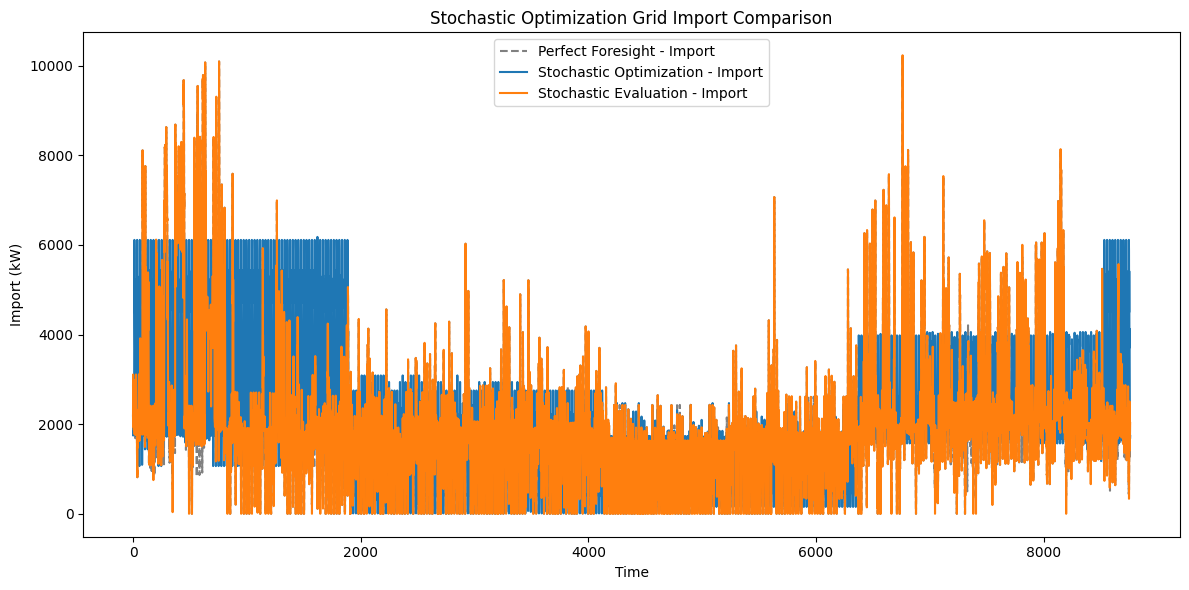

In [15]:
plt.figure(figsize=(12, 6))

plt.plot(perfect_foresight_df['grid_import'], '--', c='grey', label='Perfect Foresight - Import')
plt.plot(stochastic_final_df['grid_import_optimization'], label='Stochastic Optimization - Import')
plt.plot(stochastic_final_df['grid_import_evaluation'], label='Stochastic Evaluation - Import')
plt.legend()
plt.title('Stochastic Optimization Grid Import Comparison')
plt.xlabel('Time')
plt.ylabel('Import (kW)')

plt.tight_layout()

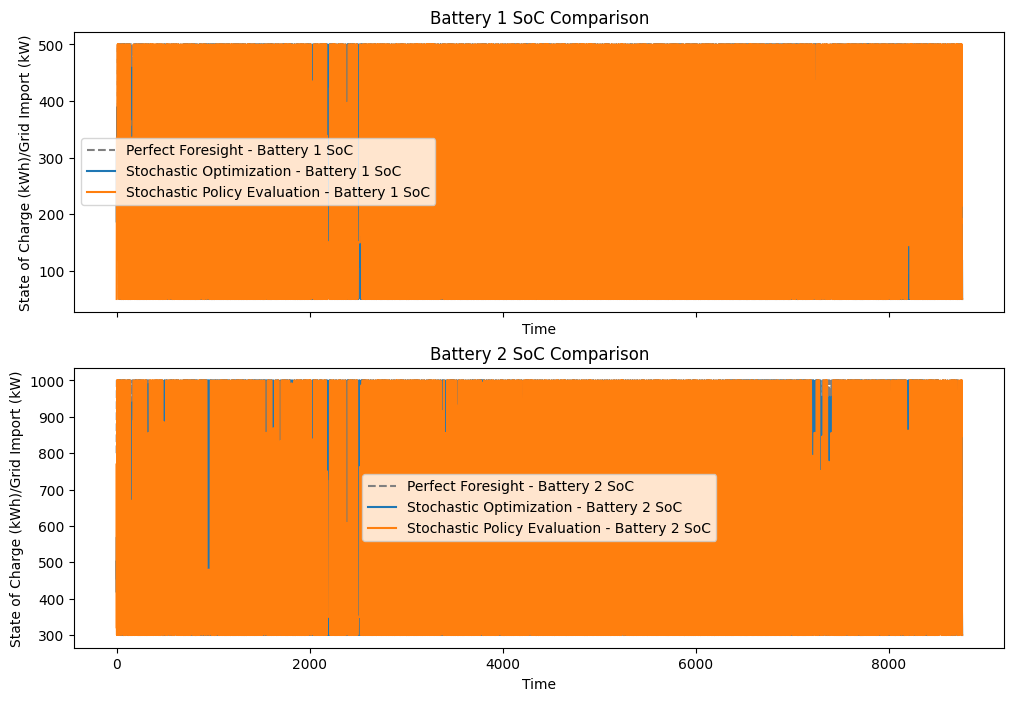

In [16]:
num_batteries = sum(["battery" in col for col in perfect_foresight_df.columns])
num_batteries //= 3

fig, axs = plt.subplots(num_batteries, 1, figsize=(12, 4*num_batteries), sharex=True)

for i in range(num_batteries):
    axs[i].plot(perfect_foresight_df[f'battery_{i+1}_soc'], '--', c='grey', label=f'Perfect Foresight - Battery {i+1} SoC')

    # axs[i].plot(stochastic_final_df[f'grid_import_evaluation'], label=f'Stochastic Policy Evaluation - Grid Import')
    axs[i].plot(stochastic_final_df[f'expected_battery_{i+1}_soc_optimization'], label=f'Stochastic Optimization - Battery {i+1} SoC')
    axs[i].plot(stochastic_final_df[f'expected_battery_{i+1}_soc_evaluation'], label=f'Stochastic Policy Evaluation - Battery {i+1} SoC')

    axs[i].legend()
    axs[i].set_title(f'Battery {i+1} SoC Comparison')
    axs[i].set_xlabel('Time')
    axs[i].set_ylabel('State of Charge (kWh)/Grid Import (kW)')

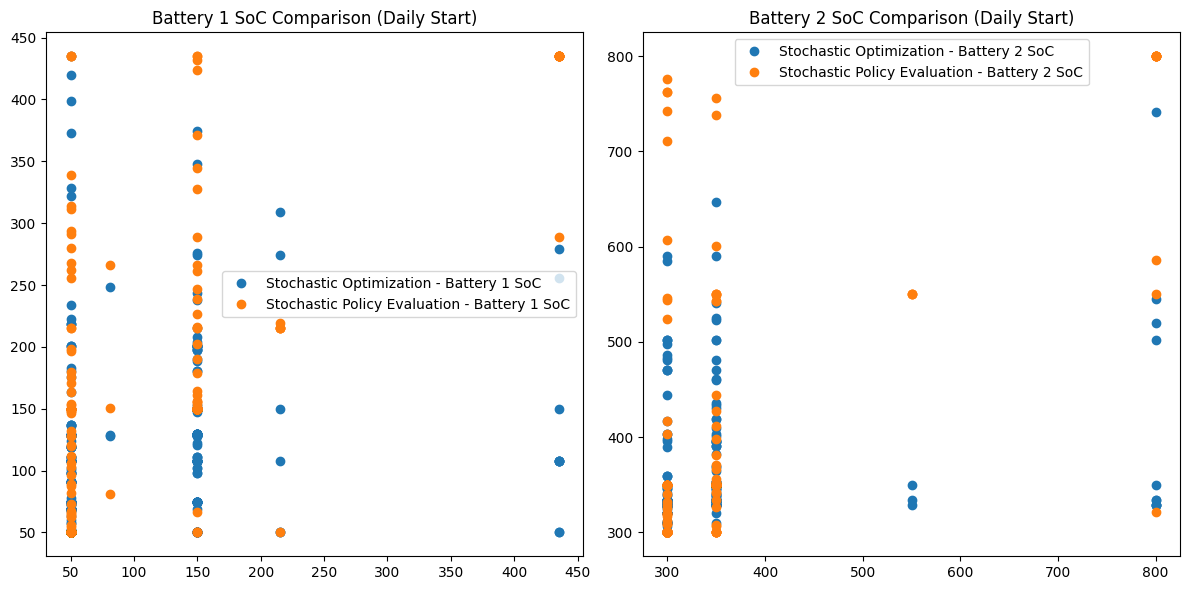

In [17]:
fig, axs = plt.subplots(1, num_batteries, figsize=(6*num_batteries, 6))

for i in range(num_batteries):
    battery_soc_x = perfect_foresight_df[f'battery_{i+1}_soc'].values.reshape(-1, 24)
    battery_soc_y_1 = stochastic_final_df[f'expected_battery_{i+1}_soc_optimization'].values.reshape(-1, 24)
    battery_soc_y_2 = stochastic_final_df[f'expected_battery_{i+1}_soc_evaluation'].values.reshape(-1, 24)
    axs[i].plot(battery_soc_x[:,0], battery_soc_y_1[:,0], 'o', label=f'Stochastic Optimization - Battery {i+1} SoC')
    axs[i].plot(battery_soc_x[:,0], battery_soc_y_2[:,0], 'o', label=f'Stochastic Policy Evaluation - Battery {i+1} SoC')

    axs[i].legend()
    axs[i].set_title(f'Battery {i+1} SoC Comparison (Daily Start)')

plt.tight_layout()


### Price Comparison

In [18]:
# Perfect Foresight
perfect_foresight_cost = (perfect_foresight_df['price'] * perfect_foresight_df['grid_import'])[non_nans].sum()
print("Total Cost with Perfect Foresight: {:.2f} EUR".format(perfect_foresight_cost))

# Stochastic Policy Evaluation
ahead_cost_evaluation = (stochastic_final_df['price_ahead_evaluation'] * stochastic_final_df['grid_import_ahead_evaluation'])[non_nans].sum()

price_rt = rt_prices_df['RT energy price (EUR/kWh)'].values
rt_cost_evaluation = (price_rt * stochastic_final_df['expected_grid_import_rt_evaluation'])[non_nans].sum()
print("Total Cost with Stochastic Policy Evaluation: {:.2f} EUR".format(ahead_cost_evaluation + rt_cost_evaluation))

diff = (ahead_cost_evaluation + rt_cost_evaluation) - perfect_foresight_cost
print("Cost of Lack of Perfect Foresight: {:.2f} EUR ({:.2f} %)".format(diff, diff / perfect_foresight_cost * 100))

Total Cost with Perfect Foresight: 1474523.21 EUR
Total Cost with Stochastic Policy Evaluation: 1484031.72 EUR
Cost of Lack of Perfect Foresight: 9508.50 EUR (0.64 %)
